In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [2]:
df = keras.datasets.mnist
(x_train,y_train),(x_test,y_test) = df.load_data()
x_train = x_train/255.0
x_test = x_test/255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 8s 1us/step


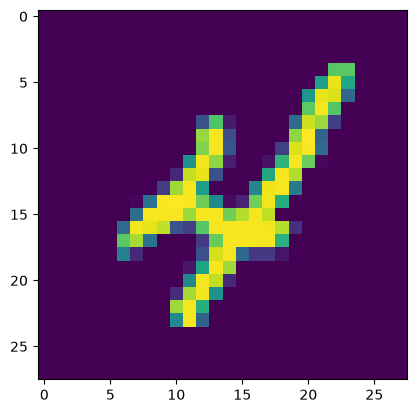

In [5]:
plt.imshow(x_train[9])

In [7]:
print(x_train.shape)
print(x_test.shape)
print(x_train[0])

(60000, 28, 28)
(10000, 28, 28)
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0

### Learning -> Always use softmax activation function in case of multiple outputs.

In [8]:
model = Sequential()

model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))

model.summary()

/Users/harshraj/Desktop/Deep-Learning/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [10]:
history = model.fit(x_train,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9176 - loss: 0.2774 - val_accuracy: 0.9580 - val_loss: 0.1438
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9645 - loss: 0.1169 - val_accuracy: 0.9683 - val_loss: 0.1053
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9749 - loss: 0.0827 - val_accuracy: 0.9685 - val_loss: 0.1040
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9816 - loss: 0.0606 - val_accuracy: 0.9672 - val_loss: 0.1111
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9850 - loss: 0.0485 - val_accuracy: 0.9710 - val_loss: 0.1051
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9870 - loss: 0.0394 - val_accuracy: 0.9738 - val_loss: 0.0967
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9896 - loss: 0.0312 - val_accuracy: 0.9728 - val_loss: 0.1092
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9914 - loss: 0

In [20]:
y_prob = model.predict(x_test)
y_pred = y_prob.argmax(axis=1)
for i in range(len(y_prob[0])):
    print(f"Probability of {i} is {y_prob[0][i]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step
Probability of 0 is 6.324524674667103e-26
Probability of 1 is 1.9336532624278989e-25
Probability of 2 is 1.4349868959731442e-24
Probability of 3 is 1.4579437975617093e-27
Probability of 4 is 0.0
Probability of 5 is 4.575300263976741e-29
Probability of 6 is 0.0
Probability of 7 is 1.0
Probability of 8 is 3.717718868147901e-30
Probability of 9 is 4.574767459067904e-18


In [21]:
y_pred

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [22]:
accuracy_score(y_test,y_pred)

0.979

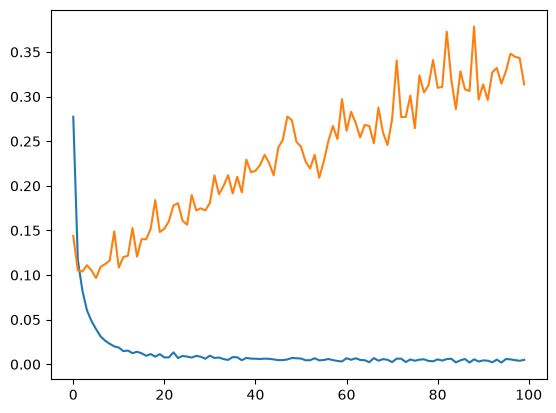

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

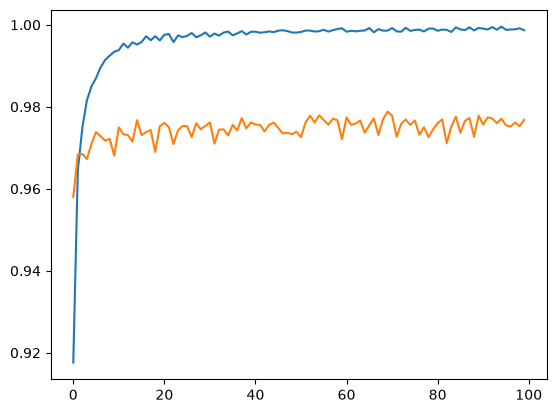

In [26]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

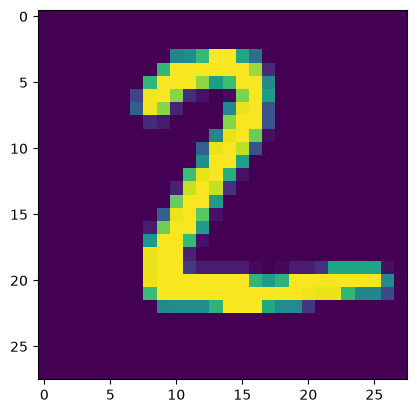

In [29]:
plt.imshow(x_test[1])

In [28]:
model.predict(x_test[1].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


array([2])